# Лабораторна робота №3
## Побудова та оцінювання моделі лінійної регресії
### Мета роботи
Набути практичних навичок розв’язання задачі регресії; навчитися відокремлювати ознаки від цільової змінної, запобігати витоку даних, розділяти вибірку на навчальну і тестову частини, порівнювати модель із базовим прогнозом та інтерпретувати MAE, RMSE і коефіцієнт детермінації R².


**Студентка:** Софія Посікера  
**Група:** МІТ-31  
**Варіант:** 20

## Опис набору даних

Для роботи використано **Bike Sharing Dataset** з UCI Machine Learning Repository.

**Джерело:** https://archive.ics.uci.edu/dataset/275/bike%2Bsharing%2Bdataset?utm_source=chatgpt.com 
**Ліцензія:** CC BY 4.0  
**Кількість спостережень:** 17 389  
**Цільова змінна:** `cnt` — загальна кількість орендованих велосипедів.

### Постановка задачі

Метою є побудова моделі лінійної регресії для прогнозування кількості орендованих велосипедів (`cnt`) на основі часових, погодних та сезонних характеристик.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

## Демонстрація набору даних ##

In [5]:
df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [6]:
print("Розмір набору даних:", df.shape)

# Типи даних у стовпцях
print("\nТипи даних:")
print(df.dtypes)

Розмір набору даних: (17379, 17)

Типи даних:
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


## Первинний аналіз даних ##

In [7]:
# Загальна інформація про набір даних
df.info()

print("Кількість пропущених значень:")
print(df.isna().sum())

print("\nКількість дублікатів:")
print(df.duplicated().sum())

print("\nОпис числових показників:")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB
Кількість пропущених значень:
instant       0
dteday        0
se

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


## Формування ознак і цільової змінної ##

In [8]:
# casual і registered — складові cnt, тому вони створюють витік даних.
X = df[["hr", "season", "workingday", "temp"]]
y = df["cnt"]

print("Розмір X:", X.shape)
print("Розмір y:", y.shape)

print("\nОзнаки X:")
print(X.head())

print("\nЦільова змінна y:")
print(y.head())

Розмір X: (17379, 4)
Розмір y: (17379,)

Ознаки X:
   hr  season  workingday  temp
0   0       1           0  0.24
1   1       1           0  0.22
2   2       1           0  0.22
3   3       1           0  0.24
4   4       1           0  0.24

Цільова змінна y:
0    16
1    40
2    32
3    13
4     1
Name: cnt, dtype: int64


## Розділення даних на навчальну і тестову вибірку ##

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=20
)

print("Розмір навчальної вибірки:", X_train.shape)
print("Розмір тестової вибірки:", X_test.shape)

Розмір навчальної вибірки: (13903, 4)
Розмір тестової вибірки: (3476, 4)


## Визначення груп ознак ##

In [10]:
numeric_features = ["temp"]
categorical_features = ["hr", "season", "workingday"]

print("Числові ознаки:", numeric_features)
print("Категоріальні ознаки:", categorical_features)

Числові ознаки: ['temp']
Категоріальні ознаки: ['hr', 'season', 'workingday']


In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

## Створення ColumnTransformer ##

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Побудова базової моделі ##

In [13]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DummyRegressor(strategy='mean'))
])

dummy_model.fit(X_train, y_train)
dummy_predictions = dummy_model.predict(X_test)

## Побудова моделі лінійної регресії ##

In [14]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

## Функція для обчислення метрик ##

In [20]:
dummy_mae = mean_absolute_error(y_test, dummy_predictions)
dummy_rmse = mean_squared_error(y_test, dummy_predictions)**0.5
dummy_r2 = r2_score(y_test, dummy_predictions)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = mean_squared_error(y_test, linear_predictions)**0.5
linear_r2 = r2_score(y_test, linear_predictions)

print("Dummy Regressor:")
print("MAE:", dummy_mae)
print("RMSE:", dummy_rmse)
print("R²:", dummy_r2)

print("\nLinear Regression:")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Dummy Regressor:
MAE: 141.51287318091724
RMSE: 178.6268123306259
R²: -2.1435251344348316e-05

Linear Regression:
MAE: 82.50865946520214
RMSE: 113.05109040407433
R²: 0.5994418948141844


In [16]:
metrics = pd.DataFrame({
    "Model": ["DummyRegressor", "LinearRegression"],
    "MAE": [dummy_mae, linear_mae],
    "RMSE": [dummy_rmse, linear_rmse],
    "R2": [dummy_r2, linear_r2]
})

metrics.to_csv("metrics.csv", index=False)

print("Файл metrics.csv збережено")

Файл metrics.csv збережено


## Розподіл цілі ##

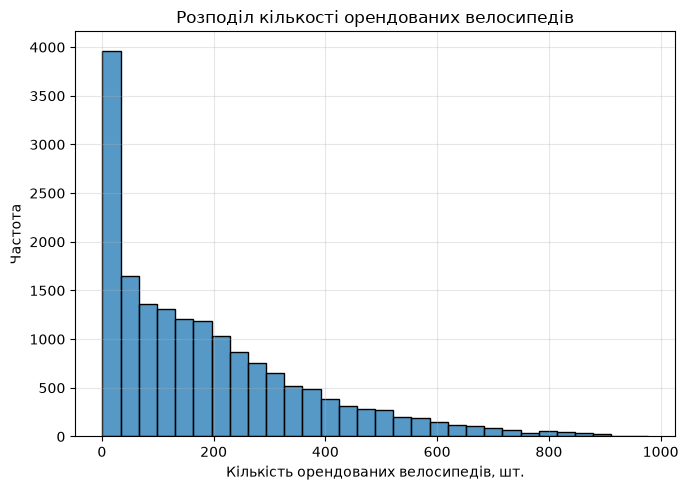

In [21]:
plt.figure(figsize=(7, 5))

sns.histplot(df["cnt"], bins=30)

plt.title("Розподіл кількості орендованих велосипедів")
plt.xlabel("Кількість орендованих велосипедів, шт.")
plt.ylabel("Частота")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("target_distribution.png", dpi=300)
plt.show()

## Фактичні та прогнозовані значення ##

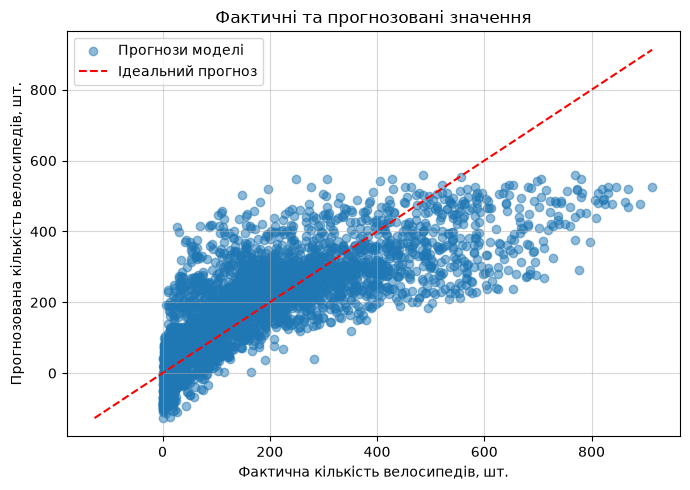

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    y_test,
    linear_predictions,
    alpha=0.5,
    label="Прогнози моделі"
)

minimum = min(y_test.min(), linear_predictions.min())
maximum = max(y_test.max(), linear_predictions.max())

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    color="red",
    label="Ідеальний прогноз"
)

ax.set(
    title="Фактичні та прогнозовані значення",
    xlabel="Фактична кількість велосипедів, шт.",
    ylabel="Прогнозована кількість велосипедів, шт."
)

ax.legend()
ax.grid(alpha=0.5)

fig.tight_layout()

plt.savefig("actual_vs_predicted.png", dpi=300)

plt.show()

## Залишки відносно прогнозу ##

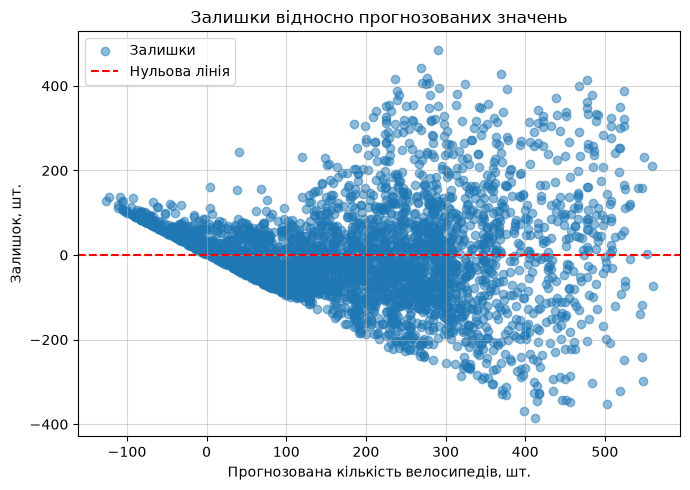

In [23]:
residuals = y_test - linear_predictions

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    linear_predictions,
    residuals,
    alpha=0.5,
    label="Залишки"
)

ax.axhline(
    0,
    linestyle="--",
    color="red",
    label="Нульова лінія"
)

ax.set(
    title="Залишки відносно прогнозованих значень",
    xlabel="Прогнозована кількість велосипедів, шт.",
    ylabel="Залишок, шт."
)

ax.legend()
ax.grid(alpha=0.5)

fig.tight_layout()

plt.savefig("residuals_vs_predicted.png", dpi=300)

plt.show()

## Формування таблиці результатів ##

In [32]:
prediction_results = X_test.copy()

prediction_results["actual_cnt"] = y_test
prediction_results["predicted_cnt"] = linear_predictions
prediction_results["residual"] = residuals

prediction_results.head()

,hr,season,workingday,temp,actual_cnt,predicted_cnt,residual
9217,23,1,1,0.32,99,19.723855,79.276145
16042,3,4,1,0.22,4,-20.855125,24.855125
13690,15,3,0,0.80,501,300.019985,200.980015
15695,4,4,0,0.36,21,9.319079,11.680921
16415,17,4,1,0.40,374,455.234482,-81.234482


In [33]:
prediction_results.to_csv("test_predictions.csv", index=False)

print("Файл test_predictions.csv збережено")

Файл test_predictions.csv збережено
